# Assignment 2: Image and Filter Techniques
In this assignment, we explore Image and Filter techniques used in computational physics

## Package Imports / Global Variables
This will be the packages used

In [26]:
from pathlib import Path
import numpy as np
# import matplotlib as mpl
# mpl.use("qtagg") # Use Qt6 backend to display images
import matplotlib.pyplot as plt
from typing import * # organizing types for function inputting / debugging
from numba import jit
import sys
!{sys.executable} -m pip install numba


In [27]:
IMG_DIR = Path('Images') #I just prefer using pathlib for directory management
MANDRILL = plt.imread(IMG_DIR / 'mandrill.png') # Find mandrill.png in the Images directory
EYE = plt.imread(IMG_DIR / 'eye.png')
PEPPERS = plt.imread(IMG_DIR / 'peppers.png')

if TYPE_CHECKING:
    from numpy.typing import ArrayLike
    from collections.abc import Sequence

## Question 1

### Part a)

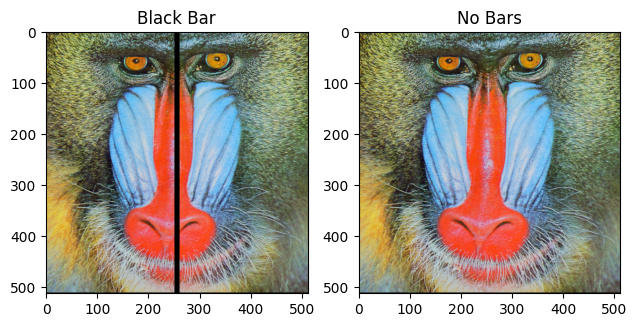

In [6]:
def black_line(img: np.ndarray, thickness: int = 10, orientation='vert') -> np.ndarray:
    """N-pixel wide lines across the entire image
    """
    if thickness > len(img):
        raise ValueError(f"Thickness of line must be less than image height: {thickness} > {img} is not allowed")
    if not isinstance(img, np.ndarray):
        raise TypeError("Must be an Array Object")
    
    image = img.copy()
    center = int(len(image)//2)
    half_width = int(thickness//2)
    
    upper = (center + half_width)
    lower = (center - half_width)
    if orientation == 'vert':
        for i, _ in enumerate(image):
            image[i][lower:upper] = [0,0,0,1]
    elif orientation == 'horiz':
        image[lower:upper] = [0,0,0,1]
    else:
        raise ValueError("kwargs 'orientation' must be either 'vert' or 'horiz'. DEFAULT: 'vert'")

    return image

#Main block, plotting
img = black_line(MANDRILL, 10)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Black Bar")
ax[1].imshow(MANDRILL)
ax[1].set_title("No Bars")
plt.tight_layout()
plt.show()



### Part b)

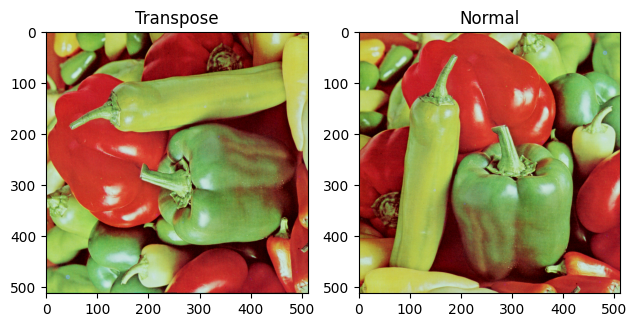

In [7]:
def transpose(img: np.ndarray) -> np.ndarray:
    if not isinstance(img, np.ndarray):
        raise TypeError("Must be an Array Object")
    image = img.copy()
    row = len(image)
    col = len(image[0])

    transpose_image = np.zeros_like(img)

    for i in range(row):
        for j in range(col):
            transpose_image[j][i] = image[i][j]
    return transpose_image

#Main block, plotting
img = transpose(PEPPERS)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Transpose")
ax[1].imshow(PEPPERS)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show()    

### Part c)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


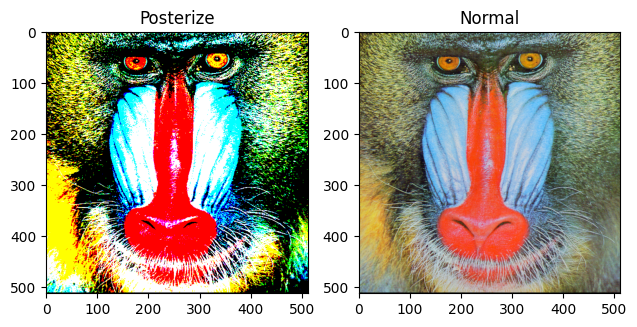

In [8]:
def posterize(img: np.ndarray, value) -> np.ndarray:

    if not isinstance(img, np.ndarray):
        raise TypeError("Must be an Array Object")
    if value > 255:
        raise ValueError("Must be less than 255")
    
    image = img.copy()
    divide = 100//value
    for i, rows in enumerate(img):
        for j, rgba in enumerate(rows):
            image[i][j][0] = rgba[0]*100//divide
            image[i][j][1] = rgba[1]*100//divide
            image[i][j][2] = rgba[2]*100//divide
    return image

#Main block, plotting
img = posterize(MANDRILL,2)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Posterize")
ax[1].imshow(MANDRILL)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show()  

## Question 2:
### Part a) Regular Compilation
Use that $$x = \left(i - \frac{n}{2}\right)\cos\theta + \left(j-\frac{m}{2}\right)\sin\theta + \frac{n}{2} $$ 
$$y = -\left(i - \frac{n}{2}\right)\sin\theta + \left(j-\frac{m}{2}\right)\cos\theta + \frac{m}{2} $$

Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
2.17 s ± 51.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Calculating in Degrees Mode


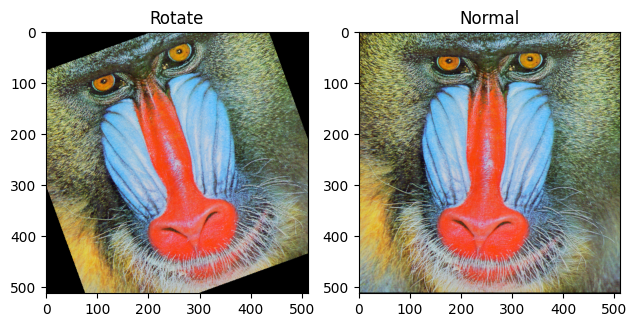

In [9]:
%timeit
def rotation(img:np.ndarray, theta: float, mode: str = 'rad'):
    n = len(img)
    m = len(img[0])
    new_image = [[[0,0,0,1] for _ in range(n)] for _ in range(m)]
    if mode == 'deg':
        print("Calculating in Degrees Mode")
        theta = theta * (np.pi/180)
    elif mode == 'rad':
        print("Calculating in Radians Mode")
    else:
        raise ValueError("mode must be either 'rad' or 'deg'.")

    for i in range(n):
        for j in range(m):
            x = (i - n/2)*np.cos(theta)+(j - m/2)*np.sin(theta) + n/2 # rotation transformation
            y = - (i - n/2)*np.sin(theta)+(j-m/2)*np.cos(theta) + m/2 # rotation transformation

            x = int(np.round(x))
            y = int(np.round(y))
            
            if (0 <= x < n) and (0 <= y < m):
                new_image[i][j] = img[x][y]
            
    return new_image

#Main block, plotting
rotation_deg = 20

%timeit img = rotation(MANDRILL,rotation_deg,mode='deg')
img = rotation(MANDRILL,rotation_deg,mode='deg')

fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Rotate")
ax[1].imshow(MANDRILL)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show() 

### Part b) Optimizing Function

Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
Calculating in Degrees Mode
1.42 s ± 22.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Calculating in Degrees Mode


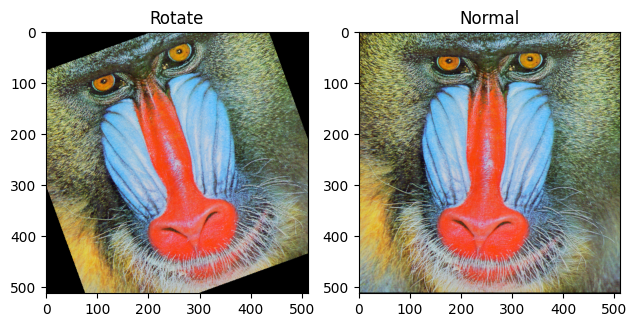

In [10]:
def rotation_optimized(img:np.ndarray, theta: float, mode: str = 'rad'):
    n = len(img)
    m = len(img[0])
    new_image = [[[0,0,0,1] for _ in range(n)] for _ in range(m)]
    if mode == 'deg':
        print("Calculating in Degrees Mode")
        theta = theta * (np.pi/180)
    elif mode == 'rad':
        print("Calculating in Radians Mode")
    else:
        raise ValueError("mode must be either 'rad' or 'deg'.")
    costheta = np.cos(theta)
    sintheta = np.sin(theta) 
    for i in range(n):
        for j in range(m):
            x = (i - n/2)*costheta+(j - m/2)*sintheta + n/2 # rotation transformation
            y = - (i - n/2)*sintheta+(j-m/2)*costheta + m/2 # rotation transformation

            x = int(np.round(x))
            y = int(np.round(y))
            
            if (0 <= x < n) and (0 <= y < m):
                new_image[i][j] = img[x][y]
            
    return new_image

#Main block, plotting
rotation_deg = 20

%timeit rotation_optimized(MANDRILL,rotation_deg,mode='deg')
img = rotation_optimized(MANDRILL,rotation_deg,mode='deg')

fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Rotate")
ax[1].imshow(MANDRILL)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show() 

### Part c) Numba's JIT Compiler Optimization

In [40]:
import math # I'm gonna use this instead of np for certain functions

@jit
def rotation_jit(img: np.ndarray, theta: float, mode: str = 'rad'):
    n, m, c = img.shape
    new_image = np.array([[[0,0,0,1] for _ in range(n)] for _ in range(m)])
    if mode == 'deg':
        print("Calculating in Degrees Mode")
        theta = theta * (math.pi/180)
    elif mode == 'rad':
        print("Calculating in Radians Mode")
    else:
        raise ValueError("mode must be either 'rad' or 'deg'.")

    costheta = math.cos(theta)
    sintheta = math.sin(theta) 

    for i in range(n):
        for j in range(m):
            x = (i - n/2)*costheta+(j - m/2)*sintheta + n/2 # rotation transformation
            y = - (i - n/2)*sintheta+(j-m/2)*costheta + m/2 # rotation transformation

            x = int(round(x))
            y = int(round(y))

            if (0 <= x < n) and (0 <= y < m):
                new_image[i][j] = img[x][y]
            
    return new_image

#Main block, plotting
rotation_deg = 20


img = rotation_jit(MANDRILL,rotation_deg,mode='deg')

fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Rotate")
ax[1].imshow(MANDRILL)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show() 

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<built-in function setitem>) found for signature:
 
 >>> setitem(array(list(int64)<iv=None>, 1d, C), int64, array(float32, 1d, C))
 
There are 16 candidate implementations:
      - Of which 16 did not match due to:
      Overload of function 'setitem': File: <numerous>: Line N/A.
        With argument(s): '(array(list(int64)<iv=None>, 1d, C), int64, array(float32, 1d, C))':
       No match.

During: typing of setitem at /tmp/ipykernel_65032/3998281566.py (27)

File "../../../../../../tmp/ipykernel_65032/3998281566.py", line 27:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference

## Question 3: Image Filters


### Part a)

In [ ]:
### KERNELS ###
LAPLACIAN = np.array([[0, 1, 0],
                      [1, -4, 1],
                      [0, 1, 0]])

SOBEL = np.array([[-1, 0, 1],
                  [1, -4, 1],
                  [0, 1, 0]])

SHARPEN = lambda alpha: np.array(
    [[0, 0, 0], 
     [0, 1, 0],
     [0, 0, 0]]
    ) - alpha*LAPLACIAN # Sharpening Kernel controlled by a factor alpha



def y_prime(img: np.ndarray, kernel: np.ndarray, i: int, j: int, m: int, n: int):
    
    return None